# LLM Evaluator

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from typing import Optional, List, Dict
from dataclasses import dataclass

@dataclass
class Job:
    title: str
    url: str
    text: Optional[str]
    searched_via: str
    low_quality: bool = False
    keep: Optional[bool] = None
    score: Optional[int] = None
    reason: str = ""
    is_ai_role: Optional[bool] = None
    is_remote_ok: Optional[bool] = None
    manual_check_required: bool = False

In [3]:
import jobs_data

production_data = jobs_data.production_data

print(len(production_data))

print(production_data[0].url)

68
https://pitchmeai.com/jobs/ciklum/expert-ai-engineer-er90haar9w


In [4]:
from openai import OpenAI
from dotenv import load_dotenv

In [5]:
load_dotenv()

True

In [6]:
llm = OpenAI()

In [7]:
system_message = """
    You are a job evaluator that analyses text based on the provided job details and description of each job.
    Your major responsibility is to filter out any Job objects that contains irrelevant text and pick out only the actual job posts(openings) BEST tailored to my desired job types.
""".strip()

In [8]:
base_user_prompt = """
    You should filter out irrelevant jobs and only pick out the best jobs that fit theese conditions:

    - They must be an AI engineer jobs (LLM Engineering, RAG, AI Agents, Agentic Systems, LoRA/QLoRA, Machine Learning or any jobs relevant in AI engineering). Otherwise keep=False.
    - they MUST be remote roles that are available for the global/worldwide regions, Asia, or South Korea. Otherwise keep=False.

    1. IMPORTANT REMOTE RULES:

    - The job MUST be accessible to a candidate residing in South Korea.
    
    - Accept if:
      - Remote worldwide / global / work from anywhere (with no spefcific regional restrcition)
      - Remote APAC / Asia (explicitly includes multiple countries, not a single country)
      - Remote with no location restriction
    
    - Reject ONLY if:
      - Remote limited to a single country (e.g., "India Remote", "US Remote", "EU Remote only")
      - Remote limited to regions that exclude South Korea
      - Visa/work authorization restriction is clearly stated

    Examples:
    - "Remote - India only" → keep = False
    - "Remote - US only" → keep = False
    - "Remote - APAC" → keep = True
    - "Remote - Worldwide" → keep = True
    - "Remote Portugal" → keep = False


    2. EDGE CASE – REMOTE JOB BOARDS:

    - If the job is sourced from a known REMOTE JOB BOARD by its url (e.g., Working Nomads, WeWorkRemotely, Remote OK):
    
      → Do NOT treat the listed country/city as a strict work location.
      → It often represents the company’s location, not a hiring restriction.
    
    - In this case:
      - Ignore the stated location
      - Analyze the full job description for actual remote constraints
    
    - If there is NO explicit country restriction:
      → set manual_check_required = True

    - If NO location mentioned or unclear:
      → set is_remote_ok = True
      → set keep = True
    
    - If you are cofnsued:
      → set manual_check_required = True


    3. OTHER RULES:
    - Reject jobs that are not clearly AI engineering roles
    - Reject non-job pages like blog posts, listings, forums, Github repos etc
    - If the job description is missing or unclear and if it might be possible for remote South Korea, mark manual_check_required = True

    
    4. TIMEZONE / WORK HOURS MATCH RULES:

    - If the required timezone or work time overlap matches Asia or South Korea → keep = True
    - If timezone overlap is reasonably manageable and the role appears practically workable from South Korea, set keep = True. There's a high chance for Korea then!
    - If overlap is difficult but still possible for South Korea(remote) → keep = True
    

    Return ONLY valid JSON in this format without any comments or explanation:

    {
        "keep": boolean (keep = True if it best fits to my target conditions described above),
        "score": int (0 to 100),
        "reason": string (short text within 150 characters), 
        "is_ai_role": boolean,
        "is_remote_ok": boolean (if available worldwide/global, or Asia/APAC, or South Korea),
        "manual_check_required": boolean
    }
""".strip()

## Call GPT

In [9]:
import json
import openai

gpt_results = []

for i, job in enumerate(production_data):

    user_prompt = base_user_prompt + f"""
    Now, evaluate the following Job:

    Title: {job.title}
    URL: {job.url}
    Text: {job.text}
    
    """.strip() 

    try:
        print(f"Job {i + 1} is being analyzed...")
        response = llm.chat.completions.create(
            model="gpt-5.4",
            messages=[
                {"role": "system", "content": system_message},
                {"role": "user", "content": user_prompt}
            ]
        )

        json_result = response.choices[0].message.content
    
        parsed_res: Dict[str, any] = json.loads(json_result)

        job.is_ai_role = parsed_res["is_ai_role"]
        job.is_remote_ok = parsed_res["is_remote_ok"]
        job.keep = parsed_res["keep"]
        job.manual_check_required = parsed_res['manual_check_required']
        job.reason = parsed_res['reason']
        job.score = parsed_res['score']

        if not job.text or len(job.text.split()) <= 150: 
            job.keep = False
    
        gpt_results.append(job)
        
    except openai.BadRequestError as e:
        print(f"Bad request: {e}")
    except openai.APIError as e:
        print(f"General OpenAI error: {e}")
    except Exception as e:
        print(f"Error calling LLM via OpenAI API: {e}")

Job 1 is being analyzed...
Job 2 is being analyzed...
Job 3 is being analyzed...
Job 4 is being analyzed...
Job 5 is being analyzed...
Job 6 is being analyzed...
Job 7 is being analyzed...
Job 8 is being analyzed...
Job 9 is being analyzed...
Job 10 is being analyzed...
Job 11 is being analyzed...
Job 12 is being analyzed...
Job 13 is being analyzed...
Job 14 is being analyzed...
Job 15 is being analyzed...
Job 16 is being analyzed...
Job 17 is being analyzed...
Job 18 is being analyzed...
Job 19 is being analyzed...
Job 20 is being analyzed...
Job 21 is being analyzed...
Job 22 is being analyzed...
Job 23 is being analyzed...
Job 24 is being analyzed...
Job 25 is being analyzed...
Job 26 is being analyzed...
Job 27 is being analyzed...
Job 28 is being analyzed...
Job 29 is being analyzed...
Job 30 is being analyzed...
Job 31 is being analyzed...
Job 32 is being analyzed...
Job 33 is being analyzed...
Job 34 is being analyzed...
Job 35 is being analyzed...
Job 36 is being analyzed...
J

In [11]:
len(gpt_results)

68

## Call Gemini

In [8]:
from google import genai
from google.genai import types
import json
from typing import Dict
import json
import time
import random

In [9]:
client = genai.Client()

In [14]:
for m in client.models.list():
    print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gem

In [16]:
def clean_json(text: str) -> str:
    text = text.strip()
    if text.startswith("```"):
        text = text.split("```")[1]
    return text.strip()


gemini_results = []

for i, job in enumerate(production_data):
    user_prompt = base_user_prompt + f"""
Now, evaluate the following Job:

Title: {job.title}
URL: {job.url}
Text: {job.text}
""".strip()

    try:
        print(f"Job {i + 1} is being analyzed...")

        response = client.models.generate_content(
            model="models/gemini-2.5-pro",
            contents=user_prompt,
            config=types.GenerateContentConfig(
                system_instruction=system_message,
                temperature=0.2,
                responseMimeType="application/json"
            )
        )

        if not response.text:
            print("Empty response")
            continue

        json_result = clean_json(response.text)

        parsed_res: Dict[str, any] = json.loads(json_result)

        job.is_ai_role = parsed_res.get("is_ai_role")
        job.is_remote_ok = parsed_res.get("is_remote_ok")
        job.keep = parsed_res.get("keep")
        job.manual_check_required = parsed_res.get("manual_check_required")
        job.reason = parsed_res.get("reason")
        job.score = parsed_res.get("score")

        if not job.text or len(job.text.split()) <= 150:
            job.keep = False

        gemini_results.append(job)

        time.sleep(random.uniform(1.0, 2.0))  # prevent rate limit

    except json.JSONDecodeError as e:
        print(f"JSON parsing error: {e}")
    except Exception as e:
        print(f"Gemini API Error: {e}")

Job 1 is being analyzed...
Job 2 is being analyzed...
Job 3 is being analyzed...
Job 4 is being analyzed...
Job 5 is being analyzed...
Job 6 is being analyzed...
Job 7 is being analyzed...
Job 8 is being analyzed...
Job 9 is being analyzed...
Job 10 is being analyzed...
Job 11 is being analyzed...
Job 12 is being analyzed...
Job 13 is being analyzed...
Job 14 is being analyzed...
Job 15 is being analyzed...
Job 16 is being analyzed...
Job 17 is being analyzed...
Job 18 is being analyzed...
Job 19 is being analyzed...
Job 20 is being analyzed...
Job 21 is being analyzed...
Job 22 is being analyzed...
Job 23 is being analyzed...
Job 24 is being analyzed...
Job 25 is being analyzed...
Job 26 is being analyzed...
Job 27 is being analyzed...
Job 28 is being analyzed...
Job 29 is being analyzed...
Job 30 is being analyzed...
Job 31 is being analyzed...
Job 32 is being analyzed...
Job 33 is being analyzed...
Job 34 is being analyzed...
Job 35 is being analyzed...
Job 36 is being analyzed...
J

## Call Claude Opus 4.7

Strength: This model is great at a deeper level of subtle nuance. It could pinpoint the exact reason why it's a remote job or not for some jobs just like at a human-reading level 

Note: Running just 68 items of a test data, it costs $1.40 on Opus 4.7 model. It charges hugely compared to GPT 5.4 or Gemini 1.5 Pro

In [53]:
import anthropic

CLAUDE_API_KEY = os.getenv("CLAUDE_API_KEY")
claude_client = anthropic.Anthropic(api_key=CLAUDE_API_KEY)

In [55]:
claude_results = []

for i, job in enumerate(production_data):
    
    user_prompt = base_user_prompt + f"""
        Now, evaluate the following Job:
        
        Title: {job.title}
        URL: {job.url}
        Text: {job.text}
    """.strip()
    
    try:
        print(f"Job {i + 1} is being analyzed...")
        response = claude_client.messages.create(
            model="claude-opus-4-7",
            max_tokens=1024,
            system=system_message,
            messages=[
                {"role": "user", "content": user_prompt}
            ]
        )

        if not response.content[0].text:
            print("Empty response")
            continue

        
        json_result = clean_json(response.content[0].text)

        parsed_res: Dict[str, any] = json.loads(json_result)

        job.is_ai_role = parsed_res.get("is_ai_role")
        job.is_remote_ok = parsed_res.get("is_remote_ok")
        job.keep = parsed_res.get("keep")
        job.manual_check_required = parsed_res.get("manual_check_required")
        job.reason = parsed_res.get("reason")
        job.score = parsed_res.get("score")

        if not job.text or len(job.text.split()) <= 150:
            job.keep = False

        claude_results.append(job)

        time.sleep(random.uniform(1.0, 2.0))  # prevent rate limit

    except json.JSONDecodeError as e:
        print(f"JSON parsing error: {e}")
    except Exception as e:
        print(f"Claude API Error: {e}")
        


Job 1 is being analyzed...
Job 2 is being analyzed...
Job 3 is being analyzed...
Job 4 is being analyzed...
Job 5 is being analyzed...
Job 6 is being analyzed...
Job 7 is being analyzed...
Job 8 is being analyzed...
Job 9 is being analyzed...
Job 10 is being analyzed...
Job 11 is being analyzed...
Job 12 is being analyzed...
Job 13 is being analyzed...
Job 14 is being analyzed...
Job 15 is being analyzed...
Job 16 is being analyzed...
Job 17 is being analyzed...
Job 18 is being analyzed...
Job 19 is being analyzed...
Job 20 is being analyzed...
Job 21 is being analyzed...
Job 22 is being analyzed...
Job 23 is being analyzed...
Job 24 is being analyzed...
Job 25 is being analyzed...
Job 26 is being analyzed...
Job 27 is being analyzed...
Job 28 is being analyzed...
Job 29 is being analyzed...
Job 30 is being analyzed...
Job 31 is being analyzed...
Job 32 is being analyzed...
Job 33 is being analyzed...
Job 34 is being analyzed...
Job 35 is being analyzed...
Job 36 is being analyzed...
J

## Evaluation Configuration

In [17]:
ground_truth_urls = [
    "https://jobs.weekday.works/arc-mid-ai-engineer---full-time---emea%2Fapac",
    "https://www.workatastartup.com/jobs/81276",
    "https://www.workingnomads.com/jobs/forward-deployed-engineer-reka",
    "https://jobs.weekday.works/gitroll-applied-ai-engineer-%E2%80%93-remote-internship-%7C-remote",
    # "https://www.workingnomads.com/jobs/forward-deployed-engineer-reka-1356307",
    "https://apply.workable.com/huggingface/", 
    "https://brainbox-automations.breezy.hr/p/7613b8687207-ai-engineer-contract-remote",
]

In [18]:
import matplotlib.pyplot as plt

gemini = "Gemini 1.5 Pro"
gpt = "GPT 5.4"
claude = "Claude Opus 4.7"

def evaluate_model(model:str, results):
    tp = []
    fp = []
    tn = []
    fn = []
    
    for result in results:
    
        pred = result.is_remote_ok
        ground_truth =  result.url in ground_truth_urls
    
        if pred and ground_truth:
            tp.append(result)
        
        elif pred and not ground_truth:
            fp.append(result)
        
        elif not pred and not ground_truth:
            tn.append(result)
            
        elif not pred and ground_truth:
            fn.append(result)
    
    labels = ["TP", "FP", "TN", "FN"]
    values = [len(tp), len(fp), len(tn), len(fn)]
    
    precision_rate = ((values[0] + values[2]) / sum(values)) * 100 
    
    plt.bar(labels, values)
    plt.title(f"{model} Model Accuracy Evaluation: {precision_rate:.2f}% Correct")
    plt.ylabel("Count")
    plt.show()


## Model Evaluation -- GPT 5.4

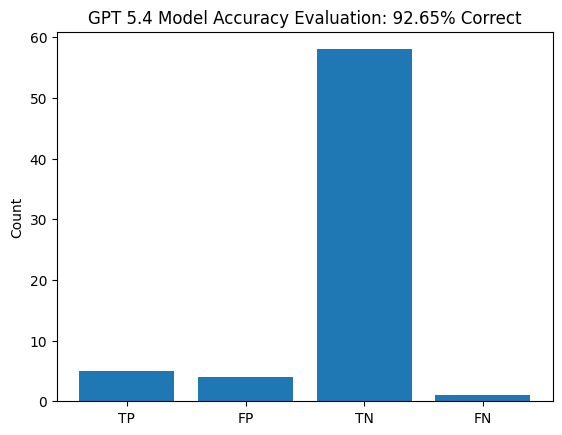

In [19]:
evaluate_model(gpt, gpt_results)

In [20]:
num_tp = []
num_fn = []
bum_fp = []

for job in gpt_results:

    # if job.keep:
    #     print(f"POS LIST:\n{job.url}\nREASON:\n{job.reason}\n\n")
    
    if job.keep: 
        print(f"TP:\nURL: {job.url}\nREASON: {job.reason}\nSCORE:{job.score}\nMCR: {job.manual_check_required}\n")
        num_tp.append(job)
    if not job.keep and job.url in ground_truth_urls:
        print(f"FN:\nURL: {job.url}\nREASON: {job.reason}\nSCORE:{job.score}\nMCR: {job.manual_check_required}\n")
        num_fn.append(job)

    if job.keep and job.url not in ground_truth_urls:
        print(f"FP:\nURL: {job.url}\nREASON: {job.reason}\nSCORE:{job.score}\nMCR: {job.manual_check_required}\n")
        bum_fp.append(job)
        
print("Number of TP: ", len(num_tp))
print("Number of FN: ", len(num_fn))
print("Number of FP: ", len(bum_fp))

TP:
URL: https://jobs.weekday.works/arc-mid-ai-engineer---full-time---emea%2Fapac
REASON: Clear AI Engineer role focused on RAG/agentic systems; remote EMEA/APAC includes South Korea via APAC.
SCORE:95
MCR: False

TP:
URL: https://jobs.lever.co/binance/fe2b0bf9-95bb-40c5-959b-f991278a1cbe
REASON: AI/LLM engineering tasks incl. RAG/agents; remote in Asia, so likely accessible from South Korea.
SCORE:81
MCR: False

FP:
URL: https://jobs.lever.co/binance/fe2b0bf9-95bb-40c5-959b-f991278a1cbe
REASON: AI/LLM engineering tasks incl. RAG/agents; remote in Asia, so likely accessible from South Korea.
SCORE:81
MCR: False

TP:
URL: https://brainbox-automations.breezy.hr/p/7613b8687207-ai-engineer-contract-remote
REASON: Clear AI engineer role, fully remote with no explicit country restriction; PKT overlap is workable from South Korea.
SCORE:91
MCR: False

TP:
URL: https://www.workatastartup.com/jobs/81276
REASON: Strong AI/LLM evals role; fully remote-friendly with workable Singapore/APAC timezon

## Model Evaluation -- Gemini 1.5 Pro

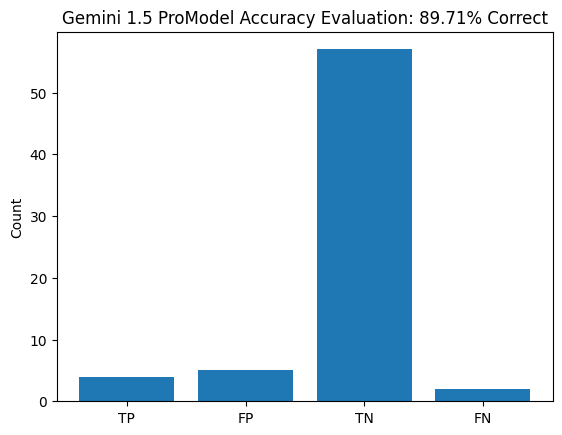

In [20]:
evaluate_model(gemini, gemini_results)

In [22]:
for job in gemini_results:

    # if job.keep:
    #     print(f"POS LIST:\n{job.url}\nREASON:\n{job.reason}\n\n")
    
    if job.keep: 
        print(f"TP:\nURL: {job.url}\nREASON: {job.reason}\nSCORE:{job.score}\nMCR: {job.manual_check_required}\n")

    if not job.keep and job.url in ground_truth_urls:
        print(f"FN:\nURL: {job.url}\nREASON: {job.reason}\nSCORE:{job.score}\nMCR: {job.manual_check_required}\n")


TP:
URL: https://jobs.weekday.works/arc-mid-ai-engineer---full-time---emea%2Fapac
REASON: The role is a perfect fit as an AI Engineer focusing on RAG and agentic systems. The location is explicitly stated as remote for EMEA/APAC, which includes South Korea.
SCORE:95
MCR: False

TP:
URL: https://internshala.com/job/detail/fresher-remote-generative-ai-engineer-job-at-growhut1772411615
REASON: Excellent AI engineering role (Generative AI, Agents, LLMs). Listed as remote without explicit geographic restrictions, but the source (Internshala) and salary in LPA suggest it may be India-focused, requiring a manual check.
SCORE:85
MCR: True

TP:
URL: https://jobs.lever.co/binance/fe2b0bf9-95bb-40c5-959b-f991278a1cbe
REASON: This is an AI/LLM software engineer role listed as remote for the Asia region, which includes South Korea. A good fit, but location needs confirmation.
SCORE:90
MCR: True

FN:
URL: https://brainbox-automations.breezy.hr/p/7613b8687207-ai-engineer-contract-remote
REASON: The r

## Claude Opus 4.7 Evaluation

In [ ]:
evaluate_model(claude, claude_results)

In [ ]:
num_tp = []
num_fn = []
bum_fp = []

for job in claude_results:

    # if job.keep:
    #     print(f"POS LIST:\n{job.url}\nREASON:\n{job.reason}\n\n")
    
    if job.keep: 
        print(f"TP:\nURL: {job.url}\nREASON: {job.reason}\nSCORE:{job.score}\nMCR: {job.manual_check_required}\n")
        num_tp.append(job)
    if not job.keep and job.url in ground_truth_urls:
        print(f"FN:\nURL: {job.url}\nREASON: {job.reason}\nSCORE:{job.score}\nMCR: {job.manual_check_required}\n")
        num_fn.append(job)

    if job.keep and job.url not in ground_truth_urls_:
        print(f"FP:\nURL: {job.url}\nREASON: {job.reason}\nSCORE:{job.score}\nMCR: {job.manual_check_required}\n")
        bum_fp.append(job)
        
print("Number of TP: ", len(num_tp))
print("Number of FN: ", len(num_fn))
print("Number of FP: ", len(bum_fp))